In [1]:
import json
from easydict import EasyDict as edict
from dataset import get_dataloader
from map_restoration import map_restore, MAPRestorationConfig
import torch

with open("config/vae_config.json", "r") as f:
    config = edict(json.load(f))

train_dl, val_dl = get_dataloader(config)

mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-d014_qmw because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.


total number of train slices: 10
total number of val slices: 5


In [2]:
for data in train_dl:
    img = data['im'].to(config.device)
    break

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


## MAP restoration

In [3]:

if __name__ == "__main__":
    from monai.networks.nets import VarAutoEncoder

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- 1. Modelo já treinado (ajuste os hiperparâmetros conforme seu treino) ---
    model = VarAutoEncoder(
        spatial_dims=2, 
        in_shape=(1, 256, 256), 
        out_channels=1,  
        latent_size=2048,  
        channels=(16, 32, 64, 128, 256, 512),  
        strides=(2, 2, 2, 2, 2, 2),  
        kernel_size=3,
        up_kernel_size=3,
        num_res_units=2,  
        act="LEAKYRELU",
        norm="BATCH",
        dropout=0.1,
    ).to(device)
    
    model.load_state_dict(torch.load("reports/vae_training/model_20.pth")['model'])
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    # --- 2. Imagens de validação saudáveis: um único tensor 4D (N, C, H, W) ---
    # (fictício: substitua pelo seu conjunto real, ex. stack de um DataLoader)
    n_val_images = 1  # ajuste aqui a quantidade desejada
    healthy_val_images = img

    cfg = MAPRestorationConfig(n_iters=10, lr_phase1=5e-3, lr_phase2=3e-3, phase1_iters=100)

    # --- 3. Escolher lambda automaticamente (Eq. 7) ---
    # `batch_size` controla quantas imagens são restauradas por vez dentro do
    # tensor 4D (útil para não estourar a memória da GPU); None = tudo junto.
    

    # --- 4. Determinar threshold para FPR alvo (ex.: 5%) ---
    print('Definindo threshold para FPR: ')


    # --- 5. Restaurar uma imagem de teste (com possível lesão) e detectar ---
    y_test = healthy_val_images  # substitua pela imagem real
    result = map_restore(model, y_test, lam=1, cfg=cfg)

    print("x_hat shape:", result["x_hat"].shape)


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Definindo threshold para FPR: 
ELBO:  metatensor(-27586.1582, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-27037.1934, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-27172.5977, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-26335.1445, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-26328.7207, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-26104.7754, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-26132.8477, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-25715.3457, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-25589.2090, device='cuda:0', grad_fn=<AliasBackward0>)
ELBO:  metatensor(-25287.6387, device='cuda:0', grad_fn=<AliasBackward0>)
x_hat shape: torch.Size([1, 1, 256, 256])


In [4]:
result

{'x_hat': metatensor([[[[0.0480, 0.0514, 0.1985,  ..., 0.0916, 0.1264, 0.2575],
           [0.0335, 0.1217, 0.2306,  ..., 0.0835, 0.1283, 0.2100],
           [0.0426, 0.1307, 0.1667,  ..., 0.1451, 0.1725, 0.1531],
           ...,
           [0.0433, 0.0567, 0.0689,  ..., 0.2219, 0.1302, 0.0521],
           [0.0520, 0.1421, 0.1759,  ..., 0.2187, 0.1210, 0.0432],
           [0.0576, 0.1946, 0.2293,  ..., 0.1379, 0.0724, 0.0391]]]],
        device='cuda:0'),
 'd_hat': metatensor([[[[-0.0480, -0.0318, -0.0377,  ..., -0.0171, -0.0127, -0.0261],
           [-0.0335, -0.0511, -0.0384,  ..., -0.0443, -0.0499, -0.0571],
           [-0.0426, -0.0601, -0.0452,  ..., -0.0588, -0.0549, -0.0629],
           ...,
           [-0.0433, -0.0370, -0.0454,  ..., -0.0611, -0.0714, -0.0521],
           [-0.0520, -0.0480, -0.0661,  ..., -0.0501, -0.0504, -0.0432],
           [-0.0576, -0.0378, -0.0449,  ..., -0.0438, -0.0293, -0.0391]]]],
        device='cuda:0'),
 'd_hat_abs': metatensor([[[[0.0480, 0.0318,

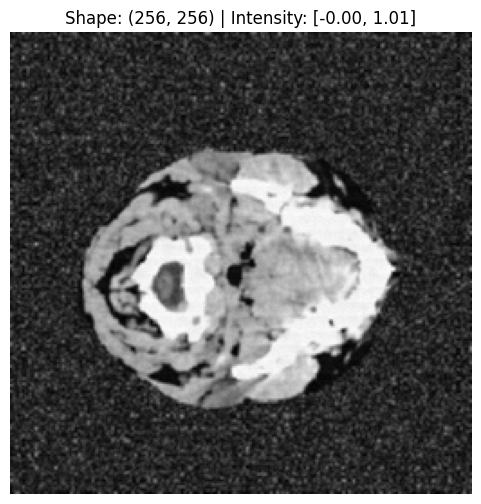

In [5]:
import matplotlib.pyplot as plt

# 1. Take the first sample and channel: (B, C, ...) -> (...)
sample = result['x_hat'][0, 0].detach().cpu().numpy()

# 2. Extract 2D slice if input is a 3D volume (H, W, D)
if sample.ndim == 3:
    slice_2d = sample[:, :, sample.shape[-1] // 2]  # Middle axial slice
else:
    slice_2d = sample  # Already 2D (H, W)
    
# 3. Plot with Matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(slice_2d, cmap="gray", origin="lower")
plt.title(f"Shape: {slice_2d.shape} | Intensity: [{slice_2d.min():.2f}, {slice_2d.max():.2f}]")
plt.axis("off")
plt.show()
